In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from nltk.tokenize import TweetTokenizer
from collections import defaultdict

In [66]:
dataset = pd.read_csv('./data/sentiment_analysis.csv',index_col='id')
dataset

,label,tweet
id,,
1,0,#fingerprint #Pregnancy Test https://goo.gl/h1...
2,0,Finally a transparant silicon case ^^ Thanks t...
3,0,We love this! Would you go? #talk #makememorie...
4,0,I'm wired I know I'm George I was made that wa...
5,1,What amazing service! Apple won't even talk to...
...,...,...
7916,0,Live out loud #lol #liveoutloud #selfie #smile...
7917,0,We would like to wish you an amazing day! Make...
7918,0,Helping my lovely 90 year old neighbor with he...


In [67]:
def text_normalize(text):
    text = re.sub(r'^RT[\s]+', '', text)

    text = re.sub(r'http?:\/\/.*[\r\n]','',text)

    text = re.sub(r'#','',text) 

    text = re.sub(r'[^\w\s]','',text)

    tokenizer = TweetTokenizer(
        preserve_case = False,
        strip_handles=True,
        reduce_len=True
    )   
    return tokenizer.tokenize(text)

In [68]:
def get_freqs(dataset):
    freqs=defaultdict(lambda: 0) 
    for idx,row in dataset.iterrows():
        tweet = row['tweet']
        label = row['label']

        tokens = text_normalize(tweet)
        for token in tokens:
            pair = (token,label)
            freqs[pair] +=1
    return freqs


In [69]:
def get_feature(text,freqs):
    tokens = text_normalize(text)
    X=np.zeros(3)
    X[0]=1
    for token in tokens:
        X[1]+=freqs[(token,0)]
        X[2]+=freqs[(token,1)]
    return X 
    

In [70]:
X = []
y=[]
freqs = get_freqs(dataset)
for idx,row in dataset.iterrows():
    tweet = row['tweet']
    label = row['label']
    X_i = get_feature(tweet,freqs)
    X.append(X_i)
    y.append(label)
X=np.array(X)
y=np.array(y)
    

In [71]:
val_size = 0.2
test_size = 0.125
random_state = 2
is_shuffle=True

X_train,X_val,y_train,y_val = train_test_split(X,y,test_size = val_size,random_state=random_state,shuffle=is_shuffle)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=test_size,random_state=random_state,shuffle=is_shuffle)


In [72]:
normalizer = StandardScaler()
X_train[:,1:] = normalizer.fit_transform(X_train[:,1:])
X_val[:,1:]=normalizer.transform(X_val[:,1:])
X_test[:,1:]=normalizer.transform(X_test[:,1:])

In [73]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

def compute_loss(y_hat,y):
    y_hat = np.clip( y_hat, 1e-7, 1- 1e-7)
    return (-y * np.log(y_hat)- (1-y) * np.log(1-y_hat)).mean()
def predict(X,theta):
    dot_product = np.dot(X,theta)
    return sigmoid(dot_product)
def compute_gradient(X,y,y_hat):
    return np.dot(X.T,(y_hat-y))/y.size
def update_theta(theta,gradient,lr):
    return theta-lr*gradient
def compute_acc(X,y,theta):
    y_hat = predict(X,theta).round()
    acc=(y_hat==y).mean()
    return acc

In [74]:
lr = 0.01
epochs = 200
batch_size = 126

np.random.seed(random_state)
theta = np.zeros(X_train.shape[1])  # ✅ Dùng X_train thay vì X_b

train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(epochs):
    train_batch_losses =[]
    train_batch_accs = []
    val_batch_losses = []
    val_batch_accs = []

    for i in range(0, X_train.shape[0], batch_size):
        X_i = X_train[i:i+batch_size]
        y_i = y_train[i:i+batch_size]
        
        y_hat = predict(X_i,theta)
        
        train_loss = compute_loss(y_hat,y_i)

        gradient = compute_gradient(X_i,y_i,y_hat)
        
        theta = update_theta(theta,gradient,lr)
        
        train_batch_losses.append(train_loss)
        train_acc = compute_acc(X_i, y_i, theta)  # ✅ Truyền X_i thay vì y_hat
        train_batch_accs.append(train_acc)

        y_val_hat = predict(X_val,theta)
        val_loss = compute_loss(y_val_hat,y_val)
        val_batch_losses.append(val_loss)
        val_acc = compute_acc(X_val, y_val, theta)  # ✅ Truyền X_val
        val_batch_accs.append(val_acc)

    train_batch_loss = sum(train_batch_losses)/len(train_batch_losses)
    train_batch_acc = sum(train_batch_accs)/len(train_batch_accs)
    val_batch_loss = sum(val_batch_losses)/len(val_batch_losses)
    val_batch_acc = sum(val_batch_accs)/len(val_batch_accs)

    train_losses.append(train_batch_loss)
    val_losses.append(val_batch_loss)
    train_accs.append(train_batch_acc)
    val_accs.append(val_batch_acc)

    # ✅ In mỗi 100 epochs thay vì mỗi batch
    print(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_batch_loss:.4f}, Train Acc: {train_batch_acc:.4f}, Val Loss: {val_batch_loss:.4f}, Val Acc: {val_batch_acc:.4f}')

Epoch 1/200, Train Loss: 0.6660, Train Acc: 0.7846, Val Loss: 0.6649, Val Acc: 0.7916
Epoch 2/200, Train Loss: 0.6203, Train Acc: 0.7861, Val Loss: 0.6189, Val Acc: 0.7924
Epoch 3/200, Train Loss: 0.5857, Train Acc: 0.7890, Val Loss: 0.5843, Val Acc: 0.7923
Epoch 4/200, Train Loss: 0.5590, Train Acc: 0.7896, Val Loss: 0.5575, Val Acc: 0.7940
Epoch 5/200, Train Loss: 0.5379, Train Acc: 0.7915, Val Loss: 0.5364, Val Acc: 0.7968
Epoch 6/200, Train Loss: 0.5209, Train Acc: 0.7929, Val Loss: 0.5194, Val Acc: 0.7979
Epoch 7/200, Train Loss: 0.5069, Train Acc: 0.7932, Val Loss: 0.5054, Val Acc: 0.7986
Epoch 8/200, Train Loss: 0.4952, Train Acc: 0.7948, Val Loss: 0.4937, Val Acc: 0.8003
Epoch 9/200, Train Loss: 0.4852, Train Acc: 0.7951, Val Loss: 0.4838, Val Acc: 0.8020
Epoch 10/200, Train Loss: 0.4766, Train Acc: 0.7952, Val Loss: 0.4753, Val Acc: 0.8010
Epoch 11/200, Train Loss: 0.4692, Train Acc: 0.7970, Val Loss: 0.4679, Val Acc: 0.8001
Epoch 12/200, Train Loss: 0.4627, Train Acc: 0.7978,

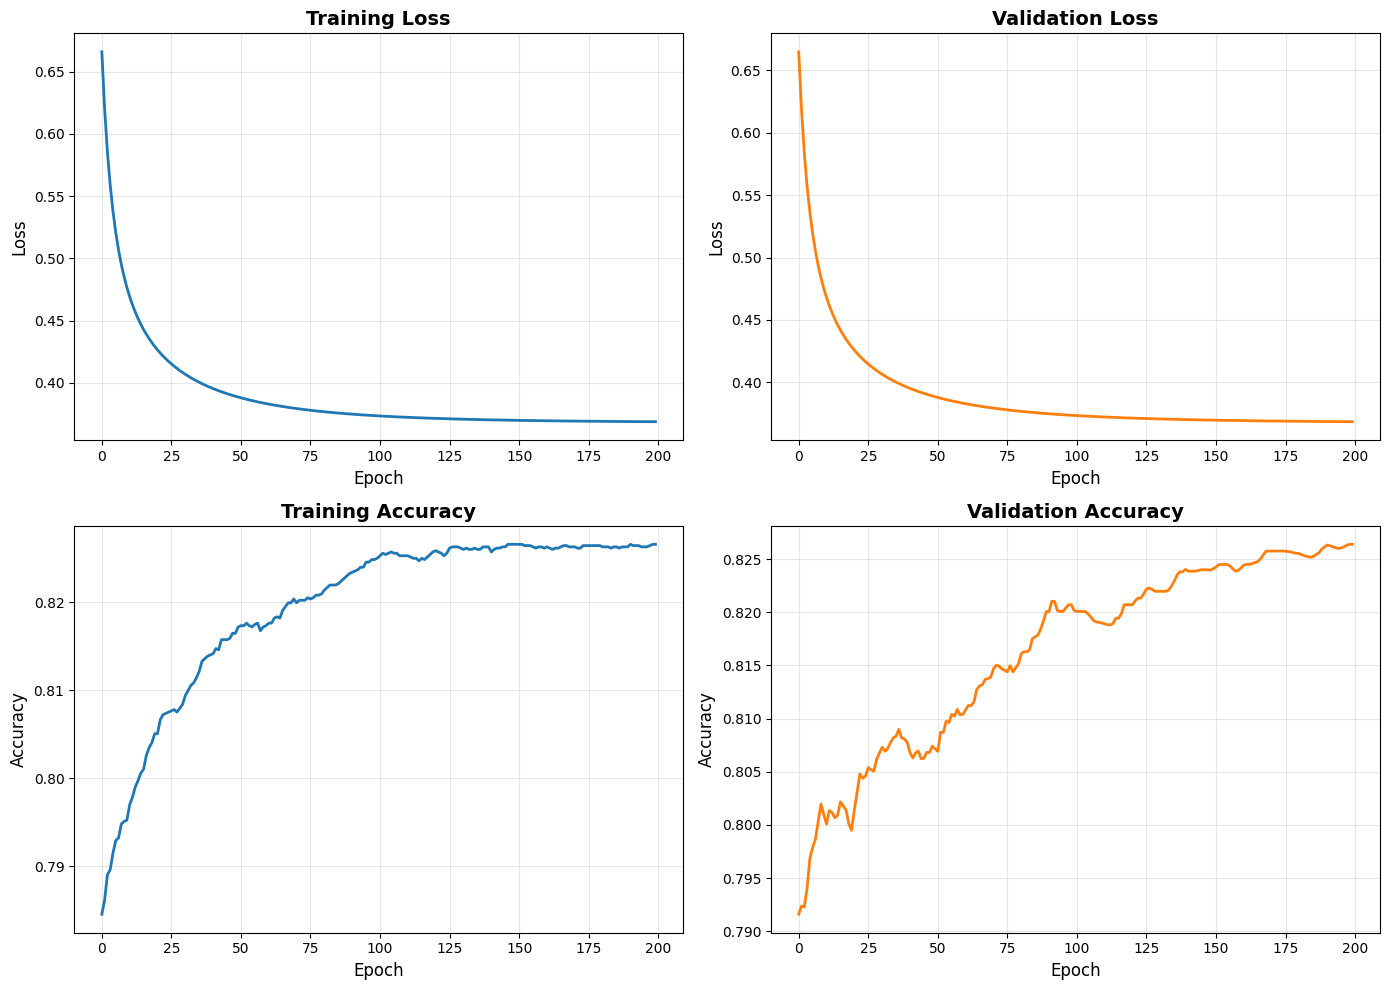

In [75]:
# Visualize Training Results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Training Loss
axes[0, 0].plot(train_losses, color='#1f77b4', linewidth=2)
axes[0, 0].set_title('Training Loss', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Loss', fontsize=12)
axes[0, 0].grid(True, alpha=0.3)

# Validation Loss
axes[0, 1].plot(val_losses, color='#ff7f0e', linewidth=2)
axes[0, 1].set_title('Validation Loss', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Loss', fontsize=12)
axes[0, 1].grid(True, alpha=0.3)

# Training Accuracy
axes[1, 0].plot(train_accs, color='#1f77b4', linewidth=2)
axes[1, 0].set_title('Training Accuracy', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('Accuracy', fontsize=12)
axes[1, 0].grid(True, alpha=0.3)

# Validation Accuracy
axes[1, 1].plot(val_accs, color='#ff7f0e', linewidth=2)
axes[1, 1].set_title('Validation Accuracy', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('Accuracy', fontsize=12)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()